In [68]:
# Verify library versions
import tdt
import neurokit2 as nk
from neurokit2 import signal_filter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import signal_processing as sp
import importlib

print("TDT version:", tdt.__version__)
print("NeuroKit2 version:", nk.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", matplotlib.__version__)

TDT version: 0.6.6
NeuroKit2 version: 0.2.10
NumPy version: 1.26.4
Pandas version: 2.2.3
Matplotlib version: 3.10.0


In [ ]:
tdt_path = r'C:\Users\tomhu\Desktop\Code\respiratory_pilot\Data\subj11-250221-085525'

mouse = tdt.read_block(tdt_path)

print(mouse)

read from t=0s to t=302.25s
epocs	[struct]
snips	[struct]
streams	[struct]
scalars	[struct]
info	[struct]
time_ranges:	array([[ 0.],
       [inf]])


In [70]:
print(f"streams data: {mouse.streams.keys()}")
print(f"epocs: {mouse.epocs.keys()}")
print(f"info data: {mouse.info.keys()}")
print(f"scalar data: {mouse.scalars.keys()}")
print(f"snips data: {mouse.snips.keys()}")

streams data: dict_keys(['Resp'])
epocs: dict_keys(['Cam1', 'Tick'])
info data: dict_keys(['tankpath', 'blockname', 'start_date', 'utc_start_time', 'stop_date', 'utc_stop_time', 'duration', 'stream_channel', 'snip_channel'])
scalar data: dict_keys([])
snips data: dict_keys([])


In [71]:
print(dir(mouse.streams['Resp']))

['__bool__', '__class__', '__class_getitem__', '__contains__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__ior__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__or__', '__reduce__', '__reduce_ex__', '__repr__', '__reversed__', '__ror__', '__setattr__', '__setitem__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'channel', 'clear', 'code', 'copy', 'data', 'dform', 'fromkeys', 'fs', 'get', 'items', 'keys', 'name', 'pop', 'popitem', 'setdefault', 'size', 'start_time', 'type', 'type_str', 'ucf', 'update', 'values']


In [72]:
# Taking array of 'Resp' Attributes
resp_stream = mouse.streams['Resp']

# Extract key attributes
resp_data = resp_stream.data
fs = resp_stream.fs
start_time = resp_stream.start_time
data_shape = resp_stream.data.shape
size = resp_data.shape[0]
channel = resp_stream.channel
stream_name = resp_stream.name


In [73]:
print(f"Sampling frequency (fs): {fs}")
print(f"Size: {size}")

# Compute total duration in seconds
total_duration = size / fs  

# Convert to minutes
total_duration_minutes = total_duration / 60  

print(f"Total duration of respiratory data: {total_duration} seconds ({total_duration_minutes} minutes)")

Sampling frequency (fs): 101.72525787353516
Size: 30744
Total duration of respiratory data: 302.2258251556456 seconds (5.037097085927427 minutes)


In [74]:
# Apply the custom filtering logic
rsp_cleaned = nk.signal_filter(
    resp_data,
    lowcut=0.1,   # Low cutoff frequency (Hz)
    highcut=20,   # High cutoff frequency (Hz)
    method="butterworth",  # Filtering method
    sampling_rate=fs,
    order=2  # Filter order
)

In [75]:
rsp_cleaned

array([ 0.00418314, -0.00499843, -0.00385679, ..., -0.00143593,
       -0.00120799, -0.00161302])

# Plotting Entire Cleaned Respiratory Signal

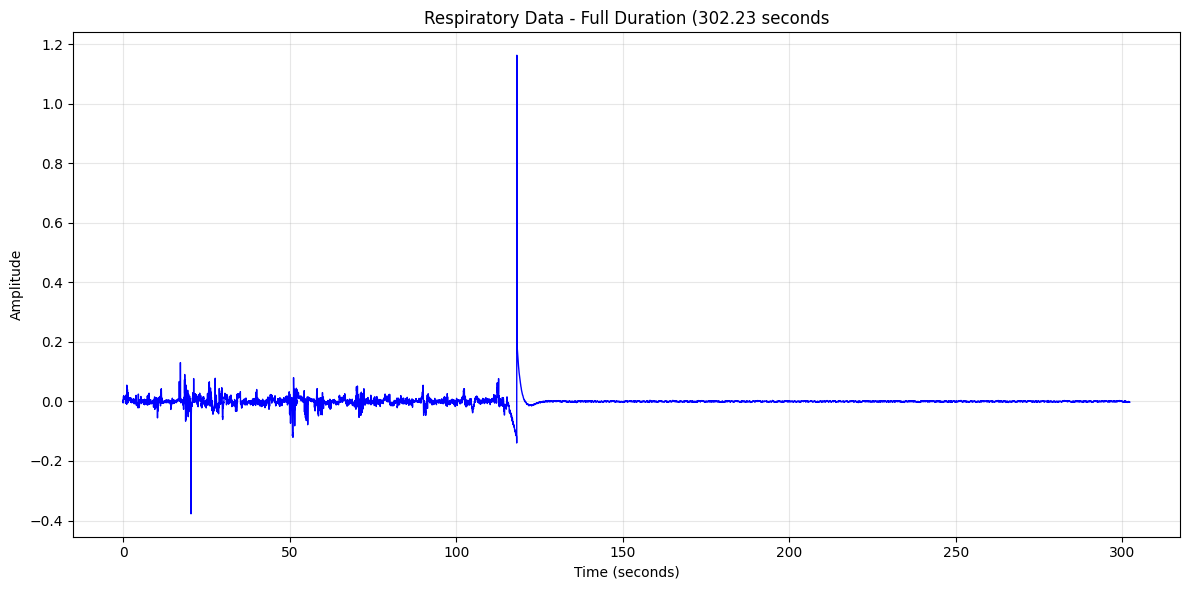

In [76]:
n_samples = len(rsp_cleaned)

# Create time array for x-axis
time = np.arange(n_samples) / fs + start_time

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(time, rsp_cleaned, 'b-', linewidth=1) 

# Add labels and title
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title(f'Respiratory Data - Full Duration ({n_samples/fs:.2f} seconds')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Plotting First 10 Seconds

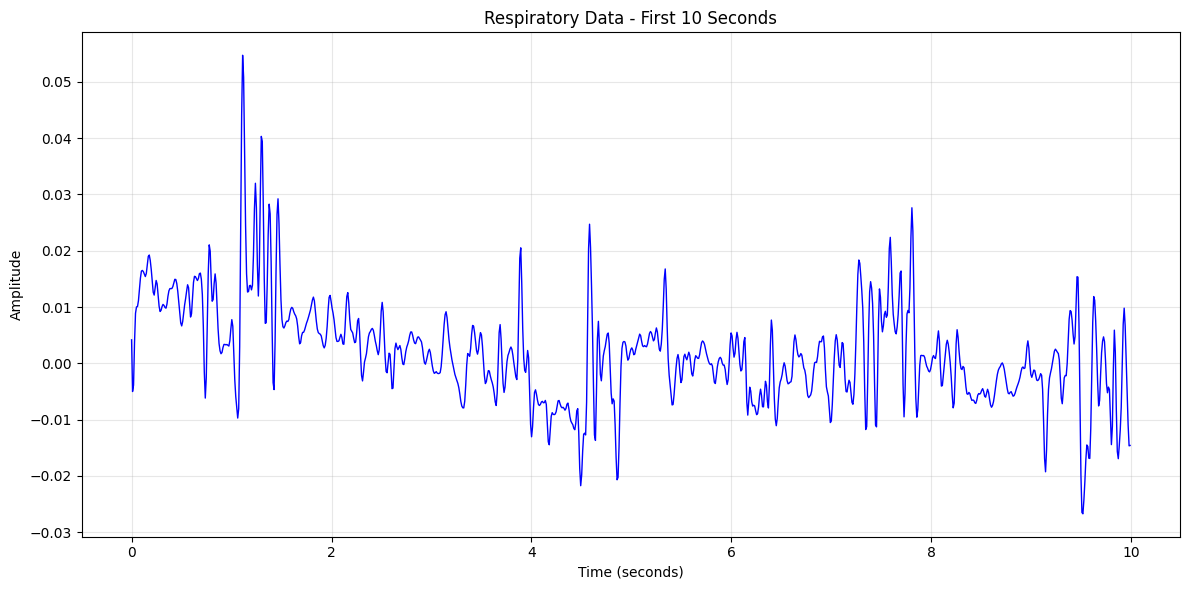

In [77]:
n_samples = int(10 * fs)

# Create time array for x-axis
time = np.arange(n_samples) / fs + start_time

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(time, rsp_cleaned[:n_samples], 'b-', linewidth=1)

# Add labels and title
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title(f'Respiratory Data - First {10} Seconds')

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Plotting second by second using a custom resp_plotting function

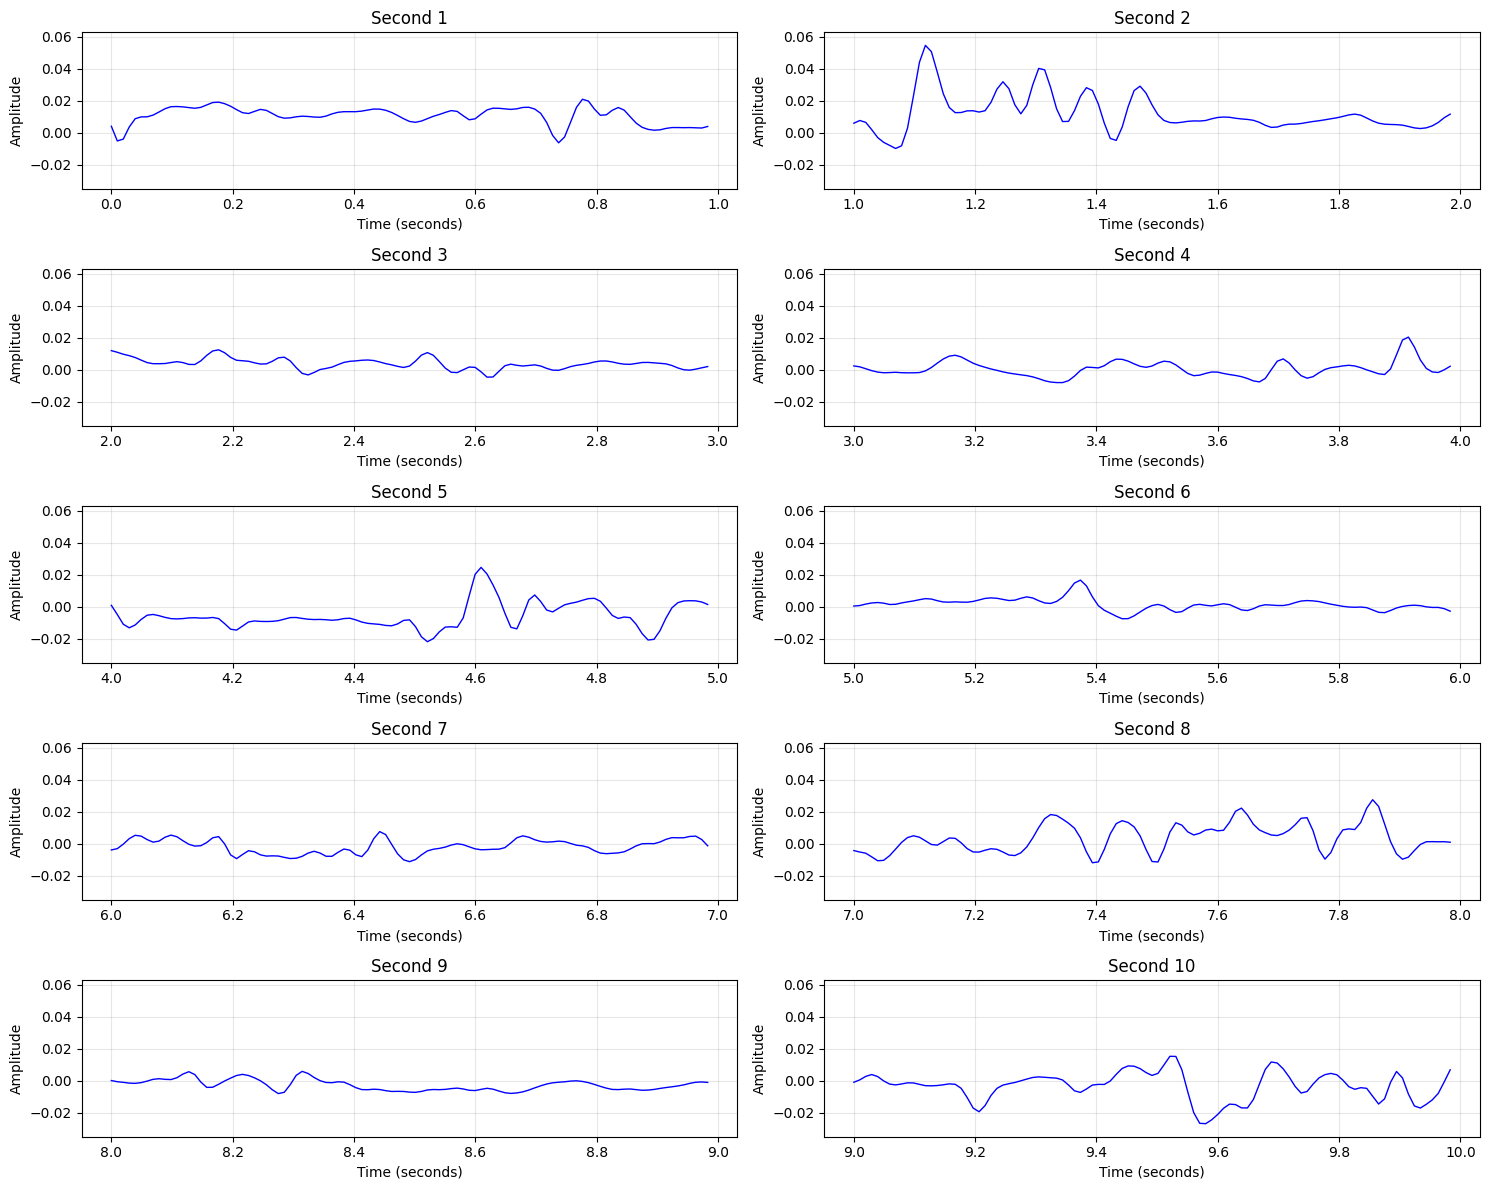

In [78]:
import resp_plotting
import importlib
importlib.reload(resp_plotting)

resp_plotting.plot_respiratory_data_by_second(rsp_cleaned, fs, start_time)


# Creating Dataframe with respiratory signal and fake Boris Data

In [79]:
# Generate timestamps
timestamps = np.arange(0, total_duration, 1/fs)  # Create time axis

# Create the respiration dataframe
resp_df = pd.DataFrame({
    "Timestamp (s)": timestamps,
    "Respiration Value": rsp_cleaned,
    "Behavioral Event": np.nan  # To be filled later from BORIS mapping
})


resp_df.head()

,Timestamp (s),Respiration Value,Behavioral Event
0,0.000000,0.004183,NaN
1,0.009830,-0.004998,NaN
2,0.019661,-0.003857,NaN
3,0.029491,0.003695,NaN
4,0.039322,0.008897,NaN


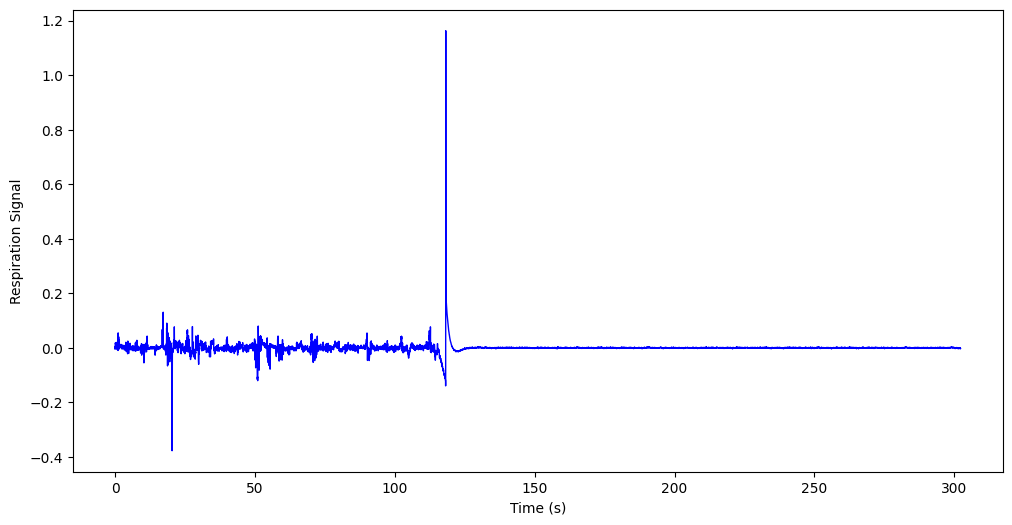

In [80]:
# Plot data
plt.figure(figsize=(12, 6))
plt.plot(resp_df["Timestamp (s)"], resp_df["Respiration Value"], 'b-', linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("Respiration Signal")
plt.show()

Loading in fake bad boris data

In [81]:
boris_path = r'C:\Users\tomhu\Desktop\Code\respiratory_pilot\BorisData\Corrected_BORIS_File.csv'

boris_data = pd.read_csv(boris_path)
boris_data.head()

,Observation id,Observation date,Description,Observation type,Source,Time offset (s),Coding duration,Media duration (s),FPS (frame/s),Subject,...,Start (s),Stop (s),Duration (s),Media file name,Image index start,Image index stop,Image file path start,Image file path stop,Comment start,Comment stop
0,Generated_Mouse_Study,2025-02-14,Synthetic Data,Anogenital,Generated Data,0,302.23,302.23,30,Mouse,...,3.814745,11.703039,7.888294,Synthetic_Session.mp4,117,1277,NaN,NaN,NaN,NaN
1,Generated_Mouse_Study,2025-02-14,Synthetic Data,Facial,Generated Data,0,302.23,302.23,30,Mouse,...,4.257948,10.964545,6.706598,Synthetic_Session.mp4,672,1748,NaN,NaN,NaN,NaN
2,Generated_Mouse_Study,2025-02-14,Synthetic Data,Flank,Generated Data,0,302.23,302.23,30,Mouse,...,18.578233,21.297359,2.719127,Synthetic_Session.mp4,924,1904,NaN,NaN,NaN,NaN
3,Generated_Mouse_Study,2025-02-14,Synthetic Data,Anogenital,Generated Data,0,302.23,302.23,30,Mouse,...,32.840256,34.342721,1.502465,Synthetic_Session.mp4,298,1932,NaN,NaN,NaN,NaN
4,Generated_Mouse_Study,2025-02-14,Synthetic Data,Facial,Generated Data,0,302.23,302.23,30,Mouse,...,39.611817,47.430069,7.818253,Synthetic_Session.mp4,589,1574,NaN,NaN,NaN,NaN


In [82]:
boris_data = boris_data[['Observation type', 'Start (s)', 'Stop (s)']]
boris_data.head()

,Observation type,Start (s),Stop (s)
0,Anogenital,3.814745,11.703039
1,Facial,4.257948,10.964545
2,Flank,18.578233,21.297359
3,Anogenital,32.840256,34.342721
4,Facial,39.611817,47.430069


Mapping behavior events to empty behavior column in the dataframe

In [83]:
# Iterate over BORIS events and map behaviors onto respiration timestamps
for _, row in boris_data.iterrows():
    start_time = row["Start (s)"]
    stop_time = row["Stop (s)"]
    behavior = row["Observation type"]

    # Mask: Find respiration timestamps that fall within the behavior window
    mask = (resp_df["Timestamp (s)"] >= start_time) & (resp_df["Timestamp (s)"] <= stop_time)

    # Assign the behavior to matching respiration timestamps
    resp_df.loc[mask, "Behavioral Event"] = behavior

C:\Users\tomhu\AppData\Local\Temp\ipykernel_23788\1684033800.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Anogenital' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  resp_df.loc[mask, "Behavioral Event"] = behavior


In [84]:
start_time = 0

In [85]:
# Around when behavior first starts in fake dataset
resp_df[(resp_df["Timestamp (s)"] >= 3.84)].head(10)

,Timestamp (s),Respiration Value,Behavioral Event
391,3.843686,-0.002407,Anogenital
392,3.853517,-0.002872,Anogenital
393,3.863347,0.000644,Anogenital
394,3.873178,0.009493,Anogenital
395,3.883008,0.018693,Anogenital
396,3.892838,0.020526,Anogenital
397,3.902669,0.014300,Anogenital
398,3.912499,0.006213,Anogenital
399,3.922330,0.000955,Anogenital
400,3.932160,-0.001249,Anogenital


# Plotting 20 seconds of Respiratory data with behavior plotted using resp_plotting 

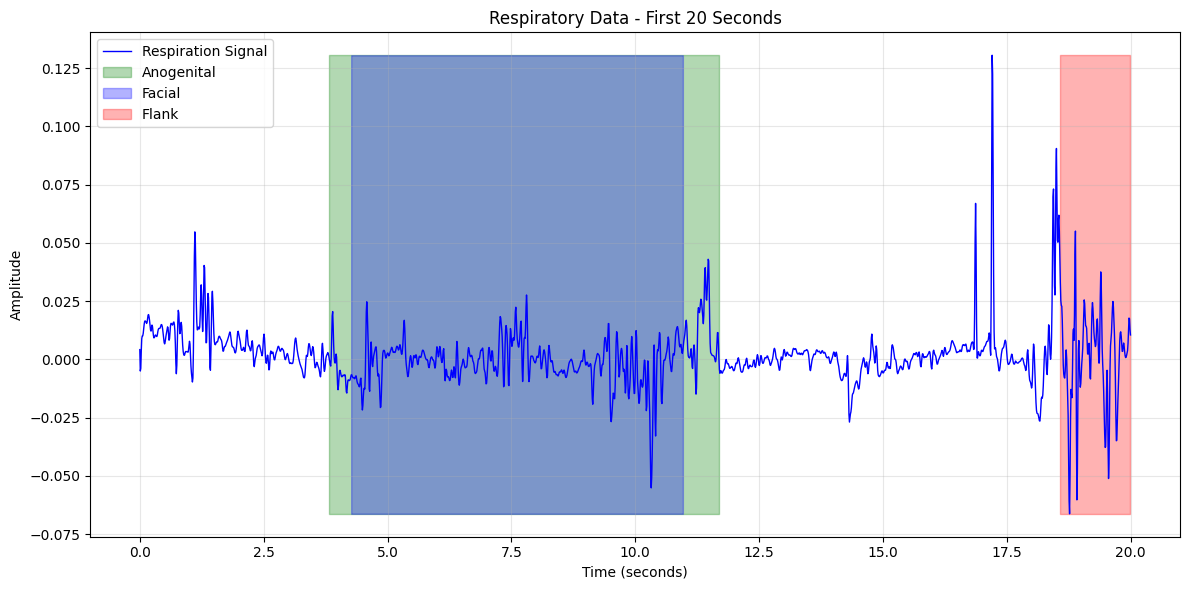

In [86]:
resp_plotting.resp_behavior_plot(resp_df, fs, start_time, duration=20)

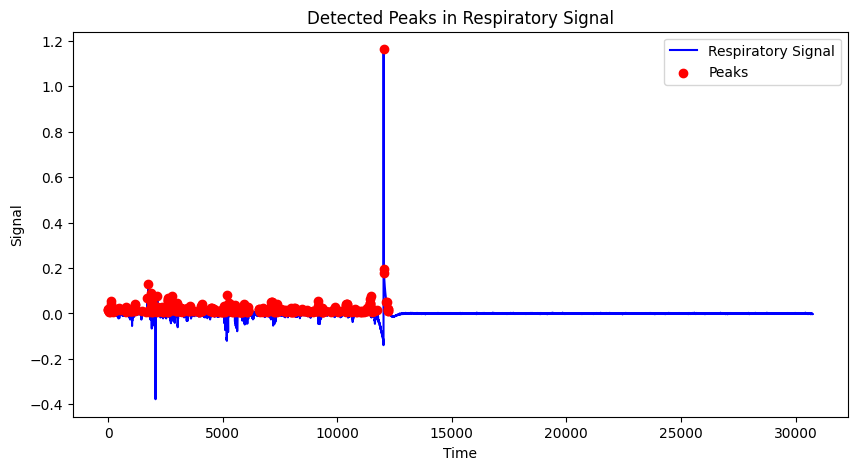

In [87]:
import signal_processing

peak_inds, peak_mags = signal_processing.peakfinder(resp_df['Respiration Value'])

# Create a new column in the DataFrame to mark detected peaks
resp_df['peak'] = 0
resp_df.loc[peak_inds.astype(int), 'peak'] = 1  # Mark peaks in the DataFrame

# Plot the signal with peaks
plt.figure(figsize=(10, 5))
plt.plot(resp_df.index, resp_df['Respiration Value'], label='Respiratory Signal', color='blue')
plt.scatter(resp_df.index[peak_inds.astype(int)], peak_mags, color='red', label='Peaks', zorder=3)
plt.xlabel('Time')
plt.ylabel('Signal')
plt.title('Detected Peaks in Respiratory Signal')
plt.legend()
plt.show()

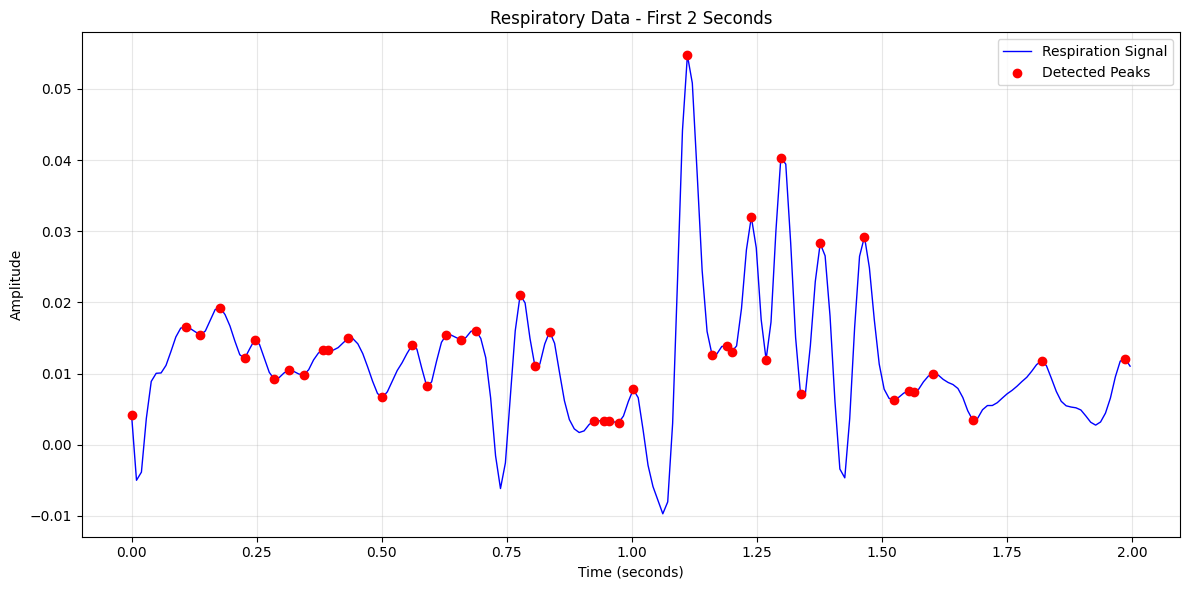

In [88]:
import importlib
importlib.reload(resp_plotting)

resp_plotting.final_resp_plot(resp_df, fs, start_time, duration=2, show_peaks=True, peak_sel=0.001, peak_thresh=0.003)

# Processing and Plotting High Frequency Areas in the Resp Data

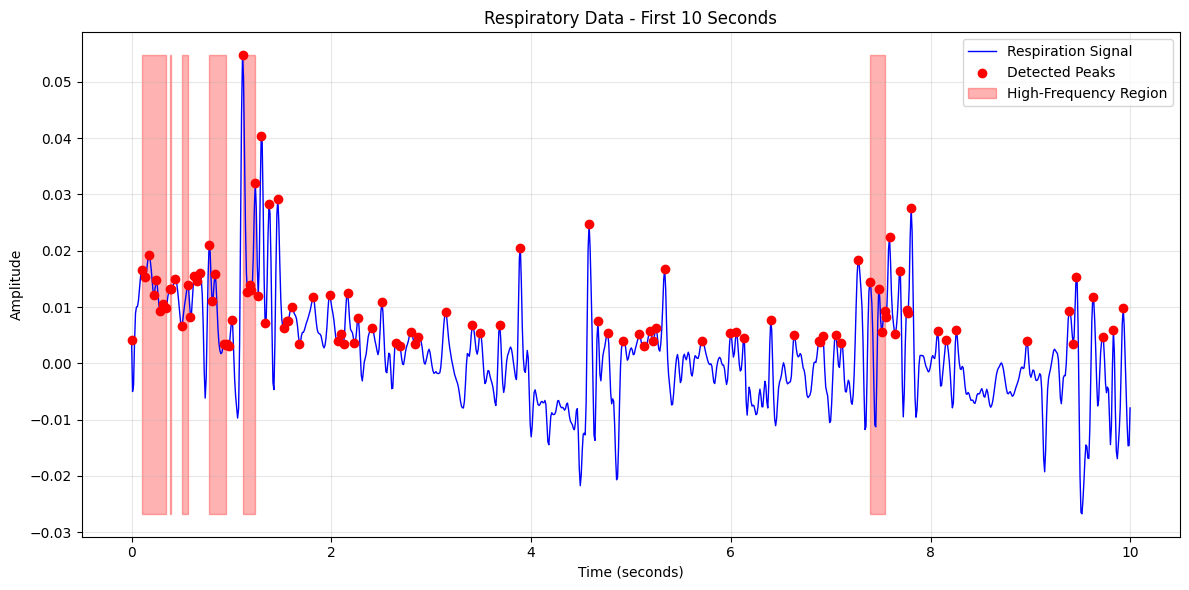

High-Frequency Regions (start, end): [(0.10813440270336006, 0.3932160098304002), (0.5603328140083204, 0.6586368164659204), (1.0027008250675207, 1.1993088299827206), (7.539916988497924, 7.549747388743684), (11.275469081886726, 11.324621083115527), (18.34352685858817, 18.44183086104577), (20.820787720519693, 21.01739572543489), (21.184512529612814, 21.282816532070413), (21.636710940917773, 21.823488545587214), (23.996006999900175, 24.133632603340814), (25.657344641433614, 25.863783046594573), (30.336615158415377, 30.503731962593296), (30.56271436406786, 30.71017036775426), (34.16064085401602, 34.24911445622786), (34.34741845868546, 35.0257160756429), (44.38425710960642, 44.43340911083523), (44.49239151230979, 44.551373913784346), (44.86594672164867, 44.974081124352026), (52.18959490473987, 52.49433731235843), (52.75975811899395, 53.08416132710403), (59.2871438821786, 59.36578708414467), (64.88064162201604, 65.09691042742276), (66.08978085224452, 66.45350566133764), (69.98261934956548, 70

In [97]:
importlib.reload(signal_processing)
importlib.reload(resp_plotting)

high_freq_regions = signal_processing.find_high_frequency_regions(resp_df, fs, window_size=5,threshold_percentile=25)

resp_plotting.final_resp_plot2(resp_df, fs, start_time, duration=10, show_peaks=True, peak_sel=0.001, peak_thresh=0.003, show_high_freq_regions=True, high_freq_threshold_percentile=20)

print("High-Frequency Regions (start, end):", high_freq_regions)